In [91]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader,TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns


**Loading dataset**

In [54]:
train_img=np.load('/content/train_images.npy')
train_label=np.load('/content/train_labels.npy')

test_img=np.load('/content/train_images.npy')
test_label=np.load('/content/train_labels.npy')

In [55]:
print(train_img.shape)
print(train_label.shape)
print(test_img.shape)
print(test_label.shape)


(60000, 28, 28)
(60000,)
(60000, 28, 28)
(60000,)


In [56]:
train_img[0].shape

(28, 28)

In [57]:
test_img[0].shape

(28, 28)

In [58]:

train_label[0]


np.uint8(5)

In [59]:
train_img[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

Text(0.5, 1.0, '5')

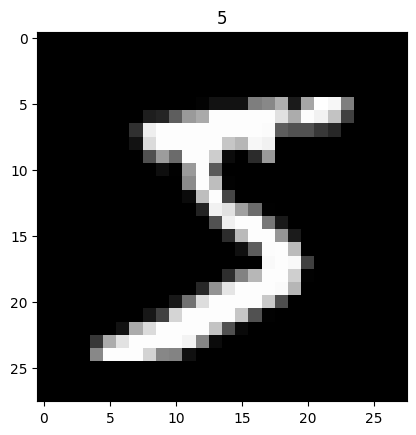

In [60]:
plt.imshow(train_img[0],cmap='gray')
plt.title(f"{train_label[0]}")

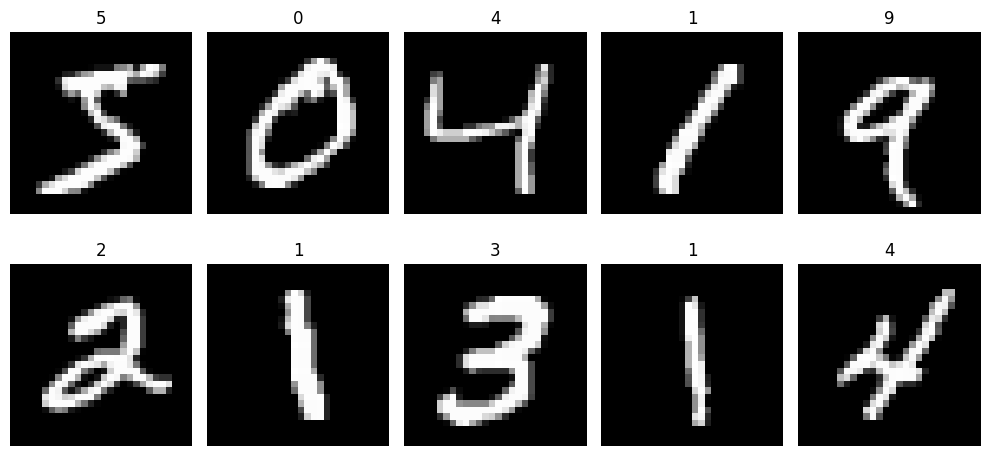

In [61]:
fig,axes=plt.subplots(2,5,figsize=(10,5))
axes=axes.flatten()
for i in range(10):
  axes[i].imshow(train_img[i],cmap='gray')
  axes[i].set_title(f"{train_label[i]}")
  axes[i].axis('off')
plt.tight_layout()


plt.show()

In [62]:
from sklearn.model_selection import train_test_split

x_train,x_val,y_train,y_val=train_test_split(train_img,train_label,test_size=0.1,random_state=42)

In [63]:
x_train=torch.tensor(x_train,dtype=torch.float32)
y_train=torch.tensor(y_train,dtype=torch.long)

x_val=torch.tensor(x_val,dtype=torch.float32)
y_val=torch.tensor(y_val,dtype=torch.long)

x_test=torch.tensor(test_img,dtype=torch.float32)
y_test=torch.tensor(test_label,dtype=torch.long)

In [64]:
train_dataset=TensorDataset(x_train,y_train)
val_dataset=TensorDataset(x_val,y_val)
test_dataset=TensorDataset(x_test,y_test)


In [65]:
train_loader = DataLoader(train_dataset ,batch_size=64 , shuffle = True)
val_loader = DataLoader(val_dataset ,batch_size=64 , shuffle = False)
test_loader = DataLoader(test_dataset ,batch_size=64 , shuffle = False)

In [74]:
class DigitClassification(nn.Module):
      def __init__(self, input_size, num_class):
          super().__init__()

          self.network=nn.Sequential(
              nn.Flatten(),
              nn.Linear(input_size,128), #1st layer = 128 neurons
              nn.ReLU(),
              nn.Linear(128,64), # 2nd layer = 64 neurons
              nn.ReLU(),
              nn.Linear(64,num_class) #Output layer
          )
      def forward(self,features):
          return self.network(features)


In [75]:
model=DigitClassification(input_size=784,num_class=10)
print(model)

DigitClassification(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [76]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=0.01)

In [78]:
epochs = 30


for epoch in range(epochs):

  running_loss = 0.0

  for images,labels in train_loader :
    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs,labels )

    loss.backward()

    optimizer.step()

    running_loss+= loss.item()

  val_loss = 0.0

  with torch.no_grad():
    for images,labels in val_loader :
      outputs = model(images)
      loss = criterion(outputs,labels)
      val_loss+= loss.item()

  print(f'Epoch {epoch+1}/ {epochs} | Train Loss : {running_loss:.4f} | Validation Loss: {val_loss:.4f}'
  )

Epoch 1/ 30 | Train Loss : 276.6324 | Validation Loss: 31.2035
Epoch 2/ 30 | Train Loss : 269.6270 | Validation Loss: 31.9329
Epoch 3/ 30 | Train Loss : 268.1558 | Validation Loss: 33.0609
Epoch 4/ 30 | Train Loss : 265.5538 | Validation Loss: 31.1690
Epoch 5/ 30 | Train Loss : 265.7745 | Validation Loss: 31.8331
Epoch 6/ 30 | Train Loss : 263.5761 | Validation Loss: 35.2154
Epoch 7/ 30 | Train Loss : 263.8230 | Validation Loss: 30.1248
Epoch 8/ 30 | Train Loss : 262.0845 | Validation Loss: 31.7865
Epoch 9/ 30 | Train Loss : 261.7071 | Validation Loss: 32.2684
Epoch 10/ 30 | Train Loss : 266.5473 | Validation Loss: 30.9583
Epoch 11/ 30 | Train Loss : 258.5287 | Validation Loss: 36.9817
Epoch 12/ 30 | Train Loss : 258.6590 | Validation Loss: 40.4422
Epoch 13/ 30 | Train Loss : 258.8272 | Validation Loss: 33.8585
Epoch 14/ 30 | Train Loss : 253.7314 | Validation Loss: 33.2299
Epoch 15/ 30 | Train Loss : 253.0574 | Validation Loss: 31.1777
Epoch 16/ 30 | Train Loss : 250.2623 | Validation

In [94]:
with torch.no_grad():
     y_pred_prob=model(x_test)
     y_pred=torch.argmax(y_pred_prob,dim=1)

print("Prediction", y_pred[:15])
print("Actual : ,", y_test[:15])

Prediction tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1])
Actual : , tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1])


Test Accuracy: 92.45%

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      5923
           1       0.96      0.97      0.96      6742
           2       0.81      0.95      0.88      5958
           3       0.96      0.83      0.89      6131
           4       0.91      0.96      0.93      5842
           5       0.90      0.87      0.88      5421
           6       0.96      0.95      0.95      5918
           7       0.96      0.96      0.96      6265
           8       0.91      0.87      0.89      5851
           9       0.94      0.91      0.92      5949

    accuracy                           0.92     60000
   macro avg       0.93      0.92      0.92     60000
weighted avg       0.93      0.92      0.92     60000



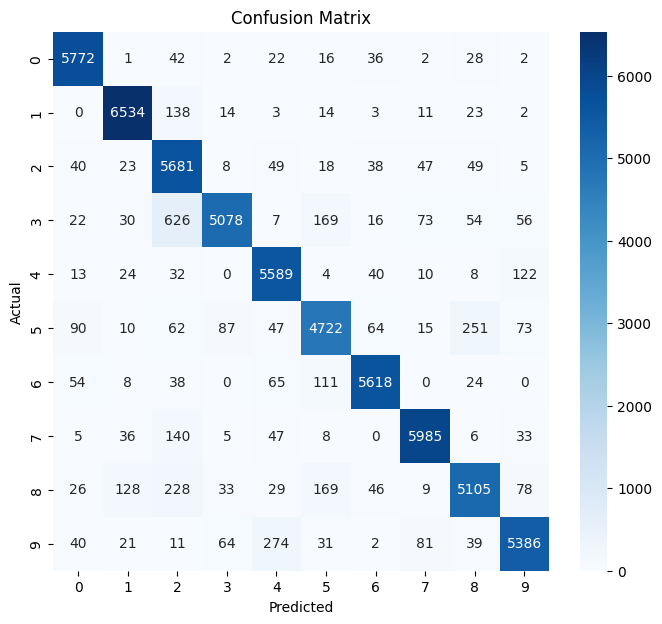

In [95]:
#Confusion Matrix
acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {acc*100:.2f}%')
print()
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()